# **IPL Data Analysis**

##**Introduction**
---

The Indian Premier League 2022 dataset contains detailed information about matches played during the 2022 season. It includes data such as teams, players, match results, venues, scores, and other key performance metrics.

This dataset is useful for analyzing team performance, player statistics, match outcomes, and trends across the tournament.

### Description of Dataset:

1. match_id : Unique ID number given to each IPL match.

2. date : The date on which the match was played.

3. venue : Stadium or ground where the match took place.

4. team1 : Name of the first team playing the match.

5. team2 : Name of the second team playing the match.

6. stage : Tournament stage of the match (League, Playoffs, Final, etc.).

7. toss_winner : Team that won the toss.

8. toss_decision : Decision taken after winning toss (Bat or Field).

9. first_ings_score : Total runs scored by the team batting first.

10. first_ings_wkts : Number of wickets lost by the first batting team.

11. second_ings_score : Total runs scored by the team batting second.

12. second_ings_wkts : Number of wickets lost by the second batting team.

13. match_winner : Team that won the match.

14. won_by : Type of win (Runs or Wickets).

15. margin : Winning margin (number of runs or wickets).

16. player_of_the_match : Best performing player in that match.

17. top_scorer : Player who scored the highest runs in the match.

18. highscore : Number of runs scored by the top scorer.

19. best_bowling : Bowler who took the best bowling performance in the match.

20. best_bowling_figure : Bowling performance in format (Wickets–Runs), e.g., 4–20.

In [ ]:
# import library for data analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
from google.colab import drive     # connect google drive with colab
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Data analysis project/IPL.csv')

In [ ]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


### **Data Exploration**
---

Check the dataset structure, columns, and basic statistics; identify missing values.

In [ ]:
# Calculate Total Runs and Total Wickets for every match
df['total_runs'] = df['first_ings_score'] + df['second_ings_score']
df['total_wickets'] = df['first_ings_wkts'] + df['second_ings_wkts']

# Display the first 10 matches with the new calculations
match_summary = df[['match_id', 'team1', 'team2', 'total_runs', 'total_wickets', 'match_winner', 'margin']]
print(match_summary.head(10))

   match_id      team1      team2  total_runs  total_wickets match_winner  \
0         1    Chennai    Kolkata         264              9      Kolkata   
1         2      Delhi     Mumbai         356             11        Delhi   
2         3   Banglore     Punjab         413              7       Punjab   
3         4    Gujarat    Lucknow         319             11      Gujarat   
4         5  Hyderabad  Rajasthan         359             13    Rajasthan   
5         6   Banglore    Kolkata         260             17     Banglore   
6         7    Chennai    Lucknow         421             11      Lucknow   
7         8    Kolkata     Punjab         278             14      Kolkata   
8         9     Mumbai  Rajasthan         363             16    Rajasthan   
9        10      Delhi    Gujarat         328             15      Gujarat   

   margin  
0       6  
1       4  
2       5  
3       5  
4      61  
5       3  
6       6  
7       6  
8      23  
9      14  


In [ ]:
df.tail()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,total_runs,total_wickets
69,70,"May 22,2022","Wankhede Stadium, Mumbai",Hyderabad,Punjab,Group,Hyderabad,Bat,157,8,...,Punjab,Wickets,5,Harpreet Brar,Liam Livingstone,49,Harpreet Brar,3--26,317,13
70,71,"May 24,2022","Eden Gardens, Kolkata",Gujarat,Rajasthan,Playoff,Gujarat,Field,188,6,...,Gujarat,Wickets,7,David Miller,Jos Buttler,89,Hardik Pandya,1--14,379,9
71,72,"May 25,2022","Eden Gardens, Kolkata",Banglore,Lucknow,Playoff,Lucknow,Field,207,4,...,Banglore,Runs,14,Rajat Patidar,Rajat Patidar,112,Josh Hazlewood,3--43,400,10
72,73,"May 27,2022","Narendra Modi Stadium, Ahmedabad",Banglore,Rajasthan,Playoff,Rajasthan,Field,157,8,...,Rajasthan,Wickets,7,Jos Buttler,Jos Buttler,106,Prasidh Krishna,3--22,318,11
73,74,"May 29,2022","Narendra Modi Stadium, Ahmedabad",Gujarat,Rajasthan,Final,Rajasthan,Bat,130,9,...,Gujarat,Wickets,7,Hardik Pandya,Shubman Gill,45,Hardik Pandya,3--17,263,12


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [ ]:
df.shape

(74, 22)

In [ ]:
print("columns :", df.columns)

columns : Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure', 'total_runs', 'total_wickets'],
      dtype='object')


In [ ]:
# see null values

df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


In [ ]:
df.describe() #It describe about mean, std, max, min

,match_id,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,margin,highscore,total_runs,total_wickets
count,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000,74.000000
mean,37.500000,171.121622,6.135135,158.540541,6.175676,16.972973,71.716216,329.662162,12.310811
std,21.505813,29.048355,2.222699,29.299207,2.639832,19.651047,20.705052,53.860875,3.038230
min,1.000000,68.000000,0.000000,72.000000,1.000000,2.000000,28.000000,140.000000,7.000000
25%,19.250000,154.250000,5.000000,142.750000,4.000000,5.250000,57.000000,301.500000,10.000000
50%,37.500000,169.500000,6.000000,160.000000,6.000000,8.000000,68.000000,326.500000,12.000000
75%,55.750000,192.750000,8.000000,176.000000,8.000000,18.000000,87.750000,363.750000,14.000000
max,74.000000,222.000000,10.000000,211.000000,10.000000,91.000000,140.000000,429.000000,19.000000


In [ ]:
# filling the numaric missing values with mean
num_col = df.select_dtypes(include=np.number).columns
df[num_col] = df[num_col].fillna(df[num_col].mean())

In [ ]:
# filling the categorical missing values with mode
cat_col = df.select_dtypes(include='object').columns
for col in cat_col:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
match_id,0
date,0
venue,0
team1,0
team2,0
stage,0
toss_winner,0
toss_decision,0
first_ings_score,0
first_ings_wkts,0


In [ ]:
# removing dublicates

### **Data Visualization**
---

Create charts (e.g., bar, line, heatmap, box plots) to visualize key trends and patterns.

<Axes: >

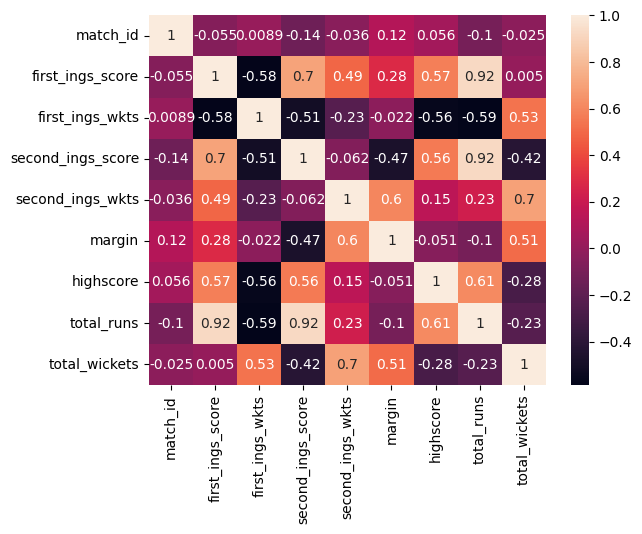

In [ ]:
sns.heatmap(df.corr(numeric_only= True), annot=True)

**Insights:**

1. **First Innings Score vs. Second Innings Score:**

Higher first innings scores correlate strongly with better second innings performance (0.7).

2. **First Innings Score vs. Total Runs:**

A high first innings score is strongly linked to higher total runs (0.92).

3. **First Innings Wickets vs. Total Wickets:**

More wickets in the first innings moderately relate to total wickets in the match (0.53).

4. **Margin vs. Highscore:**

Larger match margins are associated with higher individual high scores (0.6).

5. **Total Runs vs. Highscore:**

Higher total runs tend to correlate with higher individual scores (0.61).

In [ ]:
# df["highscore"].isnull()
df["highscore"].isnull().sum()

np.int64(0)

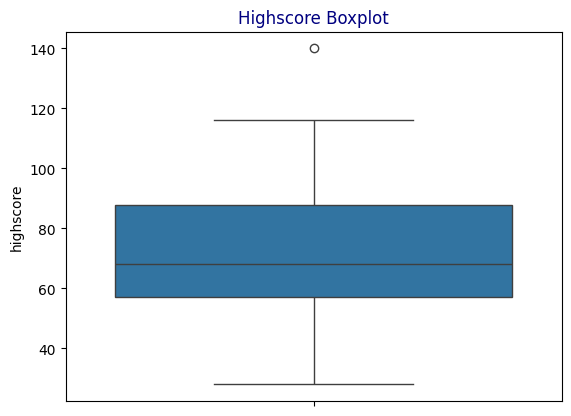

In [ ]:
sns.boxplot(df["highscore"])
plt.title("Highscore Boxplot", color = "navy")
plt.show()

**Insights:**

1. The majority of the high scores are between 60 and 100.

2. Outliers are present above 120, indicating a few exceptional performances.

3. The interquartile range (IQR) of high scores lies between 70 and 90.

4. The distribution of high scores seems centered around the mid-80s range.


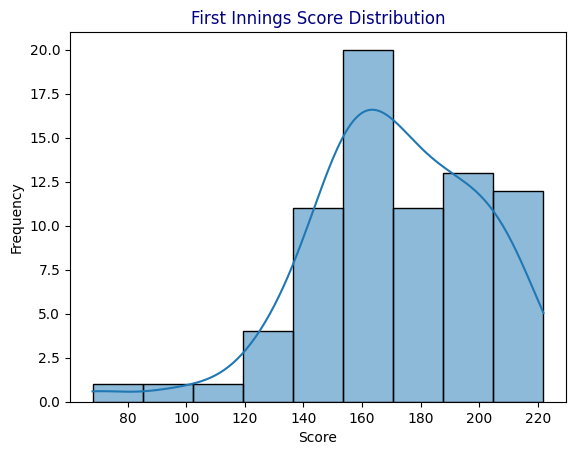

In [ ]:
sns.histplot(df['first_ings_score'], kde = True)
plt.title("First Innings Score Distribution", color = "navy")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

**Insights**

1. Most first innings scores fall between 150 and 190 runs.

2. Scores above 200 runs appear less frequently.

3. Very low scores below 120 runs are limited.

4. The distribution shows moderate variation in team scores.

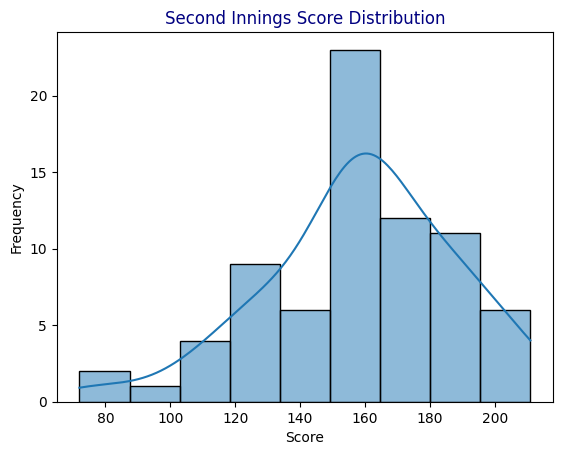

In [ ]:
sns.histplot(df['second_ings_score'], kde = True)
plt.title("Second Innings Score Distribution", color = "navy")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

**Insights**

1. Majority of second innings scores are between 140 and 180 runs.

2. High chasing scores above 190 runs are fewer.

3. Some matches show very low second innings totals.

4. The spread of scores is slightly wider compared to first innings.

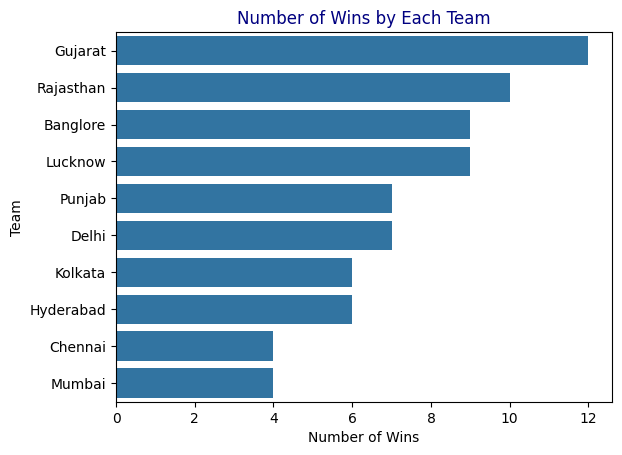

In [ ]:
wins = df['match_winner'].value_counts()

sns.barplot(x = wins.values, y = wins.index)
plt.title("Number of Wins by Each Team", color = "navy")
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.show()

**Insights**

1. **Gujarat** has the highest number of wins.

2. Teams like **Rajasthan and Banglore** also show significant wins.

3. Teams like **Chennai and Mumbai** have fewer wins in comparison.

4. **Lucknow** shows the least number of wins among the listed teams.

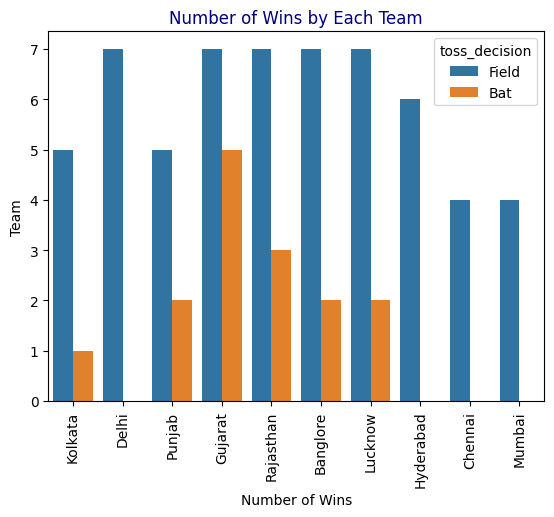

In [ ]:
sns.countplot(data = df , x = 'match_winner', hue = 'toss_decision')
plt.title("Number of Wins by Each Team", color = "navy")
plt.xticks(rotation = 90)
plt.xlabel("Number of Wins")
plt.ylabel("Team")
plt.show()

**Insights**
1. Most teams, such as **Gujarat, Hyderabad, and Banglore**, tend to win more often when they field first.

2. Lucknow shows a significant number of wins when they bat first.

3. Teams like **Kolkata and Delhi** have a more balanced win distribution between batting and fielding choices.

In [ ]:
#Check wheather toss winner are same as match winner
same_winner = df["toss_winner"] == df["match_winner"]
print(same_winner)

0      True
1      True
2      True
3      True
4     False
      ...  
69    False
70     True
71    False
72     True
73    False
Length: 74, dtype: bool


In [ ]:
count = (same_winner.value_counts() / len(same_winner) ) * 100
print(count)

False    51.351351
True     48.648649
Name: count, dtype: float64


Text(0, 0.5, 'Number of Matches')

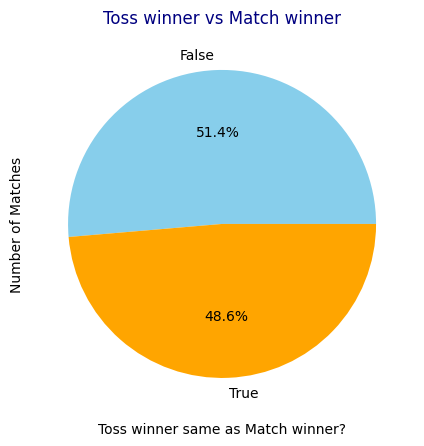

In [ ]:
# Pie Chart Plotting
plt.figure(figsize = (5, 5))
plt.pie(count.values, labels = count.index, autopct = "%1.1f%%",
        colors = ["skyblue","orange"])
plt.title("Toss winner vs Match winner", color = "navy")
plt.xlabel("Toss winner same as Match winner?")
plt.ylabel("Number of Matches")

**Insights**

1. The chart shows that in **51.4%** of the matches, the toss winner was not the match winner.

2. In **48.6%** of the matches, the toss winner also won the match.

3. The results are almost balanced, suggesting the toss decision does not heavily influence match outcomes.

In [ ]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure', 'total_runs', 'total_wickets'],
      dtype='object')

In [ ]:
team_margin = df.groupby("match_winner")["margin"].max().sort_values(ascending=False).head(10)

In [ ]:
team_margin

,margin
match_winner,
Chennai,91
Lucknow,75
Banglore,67
Gujarat,62
Rajasthan,61
Kolkata,54
Punjab,54
Delhi,44
Hyderabad,9


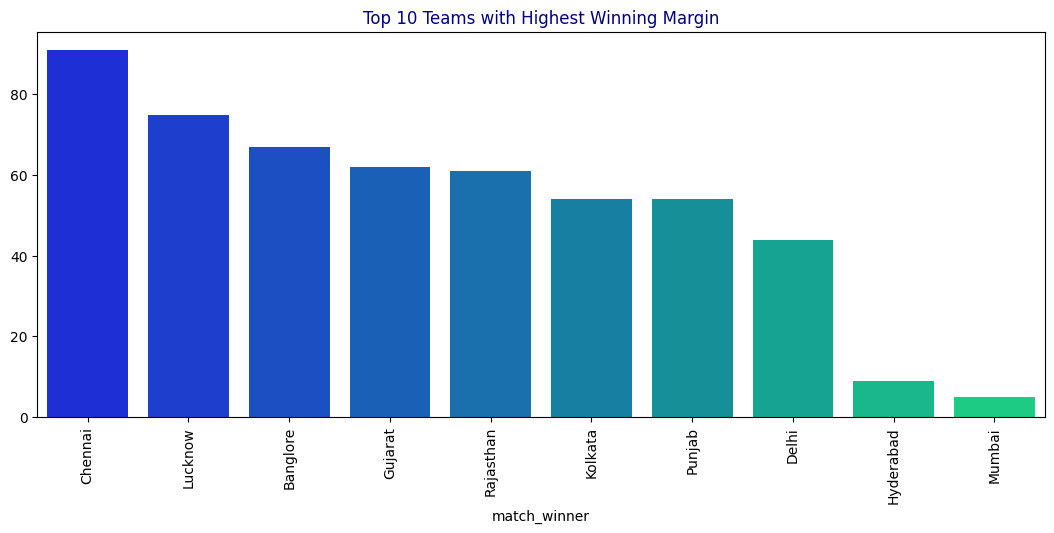

In [ ]:
# Which team win by highest margin

plt.figure(figsize=(13,5))
sns.barplot(x = team_margin.index, y = team_margin.values, palette="winter")
plt.xticks(rotation = 90)
plt.title("Top 10 Teams with Highest Winning Margin", color = "navy")
plt.show()

**Insights**

1. **Chennai** has the highest winning margin among the teams.

2. **Lucknow and Banglore** also have significant winning margins.

3. Teams like **Mumbai and Rajasthan** have lower winning margins.

4. Overall, **Gujarat and Rajasthan** also stand out with competitive margins.


In [ ]:
high_score = df.groupby("top_scorer")["highscore"].max().sort_values(ascending = False).head(10)

In [ ]:
high_score

,highscore
top_scorer,
Quinton de Kock,140
Jos Buttler,116
Rajat Patidar,112
KL Rahul,103
Ruturaj Gaikwad,99
Faf du Plessis,96
Shubman Gill,96
Shivam Dube,95
David Miller,94


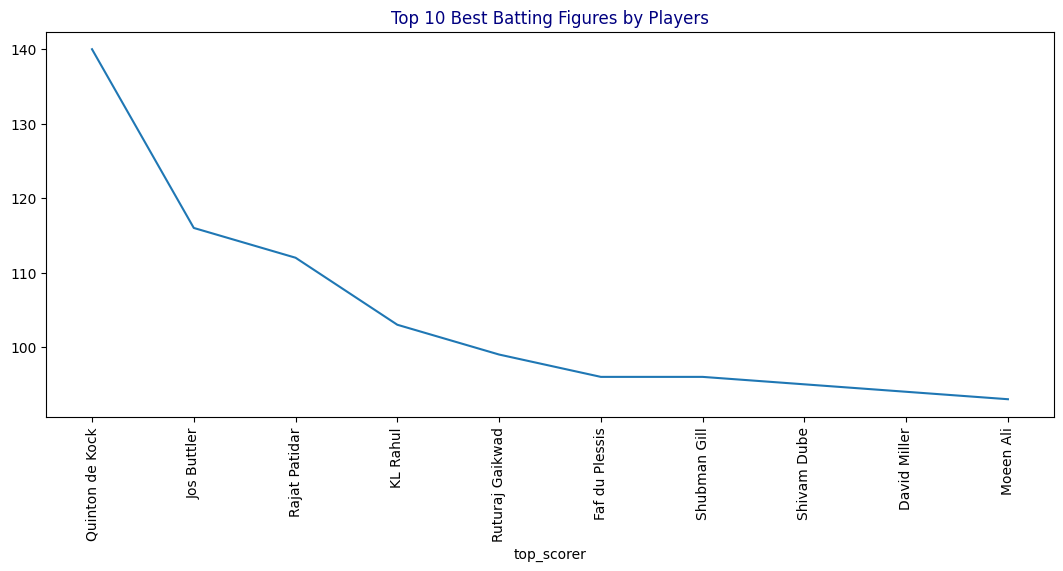

In [ ]:
# Which player had the best bowling figures

plt.figure(figsize = (13, 5))
sns.lineplot(x = high_score.index, y = high_score.values, palette = "winter")
plt.xticks(rotation = 90)
plt.title("Top 10 Best Batting Figures by Players", color = "navy")
plt.show()

**Insights**

1. **Quinton de Kock** has the highest top score, with a steep drop-off.

2. **Jos Buttler and Rajat Patidar** follow with notable scores.

3. The graph shows that **Moeen Ali** has one of the lowest top scores among the players listed.

4. The figures decrease steadily for most players after the peak.


In [ ]:
best_bowl = df.groupby("best_bowling")["best_bowling_figure"].max().sort_values(ascending = False).head(10)

In [ ]:
best_bowl

,best_bowling_figure
best_bowling,
Yuzvendra Chahal,5--40
Umran Malik,5--25
Wanindu Hasaranga,5--18
Jasprit Bumrah,5--10
Andre Russell,4--5
Mukesh Choudhary,4--46
Kagiso Rabada,4--38
Shardul Takur,4--36
Kuldeep Yadav,4--35


In [ ]:
# split first
df[["wk", "rn"]] = df["best_bowling_figure"].str.split("--", expand=True)

In [ ]:
df["wk"] = df["wk"].astype(int)   # convert object(string) data type to integer

df["rn"] = df["rn"].astype(int)

In [ ]:
# groupby bowler
bowler_perfect = df.groupby("best_bowling").agg({"wk": "max", "rn": "min"}).reset_index()

In [ ]:
# now sort
best_bowler = bowler_perfect.sort_values(["wk", "rn"],ascending=[False, True]).head(10)

In [ ]:
best_bowler

,best_bowling,wk,rn
9,Jasprit Bumrah,5,10
41,Yuzvendra Chahal,5,15
39,Wanindu Hasaranga,5,18
38,Umran Malik,5,25
0,Andre Russell,4,5
15,Kuldeep Yadav,4,14
4,Daniel Sams,4,16
21,Mohsin Khan,4,16
1,Avesh Khan,4,19
14,Kuldeep Sen,4,20


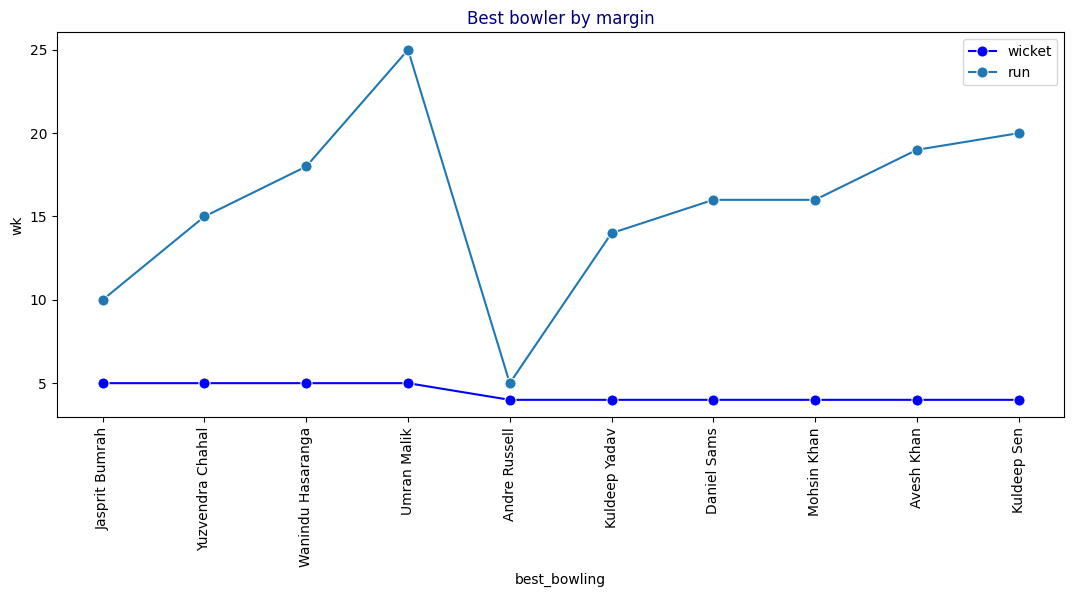

In [ ]:
# Which bowler had the best bowling figures

plt.figure(figsize = (13, 5))

sns.lineplot( x = best_bowler["best_bowling"], y = best_bowler["wk"], label = "wicket", marker="o", markersize = 8, color = "blue")
sns.lineplot( x = best_bowler["best_bowling"], y = best_bowler["rn"], label = "run", marker="o", markersize = 8, palette = "winter")

plt.xticks(rotation = 90)
plt.title("Best bowler by margin", color = "navy")
plt.show()

**Insights**

1. **Jasprit Bumrah** has the highest number of wickets with a strong increase in margin.

2. **Yuzvendra Chahal and Wanindu Hasaranga** follow closely with notable performances.

3. Other bowlers like **Andre Russell and Kuldeep Yadav** show less significant variations in wickets and runs.


In [ ]:
df["total_runs"] = df["first_ings_score"] + df["second_ings_score"]   # total runs of two innings

In [ ]:
df[["team1", "team2", "total_runs"]].head(10)

,team1,team2,total_runs
0,Chennai,Kolkata,264
1,Delhi,Mumbai,356
2,Banglore,Punjab,413
3,Gujarat,Lucknow,319
4,Hyderabad,Rajasthan,359
5,Banglore,Kolkata,260
6,Chennai,Lucknow,421
7,Kolkata,Punjab,278
8,Mumbai,Rajasthan,363
9,Delhi,Gujarat,328


In [ ]:
df_team = df["team1"] + " vs " + df["team2"]

In [ ]:
df_team.head(10)

,0
0,Chennai vs Kolkata
1,Delhi vs Mumbai
2,Banglore vs Punjab
3,Gujarat vs Lucknow
4,Hyderabad vs Rajasthan
5,Banglore vs Kolkata
6,Chennai vs Lucknow
7,Kolkata vs Punjab
8,Mumbai vs Rajasthan
9,Delhi vs Gujarat


In [ ]:
data = df["total_runs"].sort_values(ascending = False).head(10)

In [ ]:
data

,total_runs
33,429
29,427
6,421
65,418
2,413
21,409
71,400
39,394
49,393
45,391


In [ ]:
 # top 10 total_runs by match between two teams
result = pd.DataFrame({"Match": df_team.loc[data.index], "Total Runs": data})

In [ ]:
result

,Match,Total Runs
33,Delhi vs Rajasthan,429
29,Kolkata vs Rajasthan,427
6,Chennai vs Lucknow,421
65,Kolkata vs Lucknow,418
2,Banglore vs Punjab,413
21,Banglore vs Chennai,409
71,Banglore vs Lucknow,400
39,Gujarat vs Hyderabad,394
49,Delhi vs Hyderabad,393
45,Chennai vs Hyderabad,391


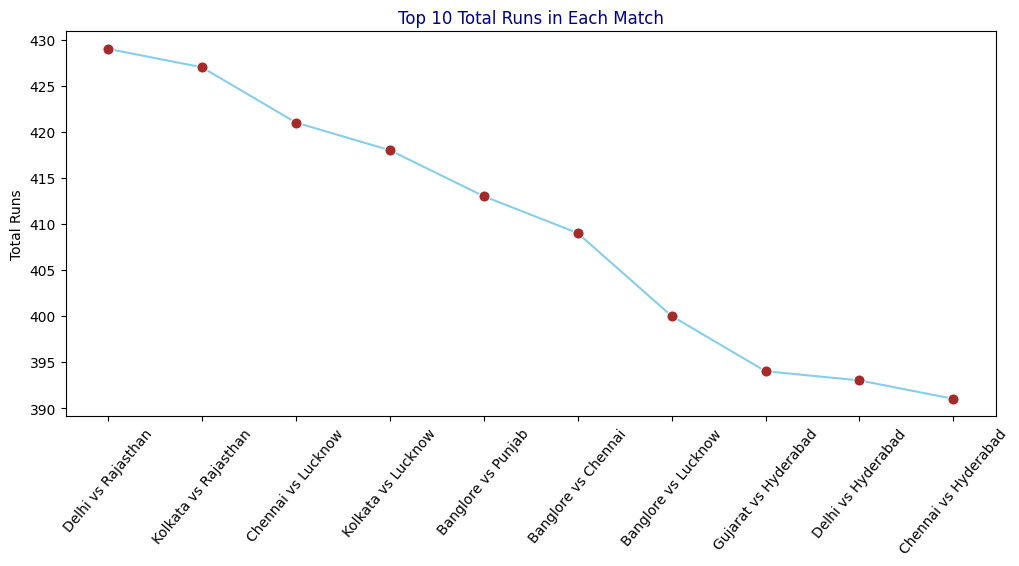

In [ ]:
plt.figure(figsize = (12, 5))
sns.lineplot(x = result["Match"].values,
             y = result["Total Runs"].sort_values(ascending = False),
             marker = "o",
             color = "skyblue",
             markerfacecolor ="brown",  # This changes the marker color
             markersize = 8)

plt.title("Top 10 Total Runs in Each Match", color = "navy")
plt.ylabel("Total Runs")
plt.xticks(rotation = 50)
plt.show()

**Insights**

1. The total runs across different matches show a steady decline.

2. **Delhi vs. Rajasthan and Kolkata vs. Rajasthan** have the highest total runs.

3. Matches involving teams like **Delhi vs. Hyderabad and Chennai vs. Hyderabad** have the lowest total runs.

In [ ]:
# Which player won most Player of the Match awards ?
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,total_runs,total_wickets,wk,rn
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,264,9,3,20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,356,11,3,18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,413,7,2,59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,319,11,3,25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,359,13,3,22


In [ ]:
top_pom = df["player_of_the_match"].value_counts().head(5)

In [ ]:
top_pom

,count
player_of_the_match,
Kuldeep Yadav,4
Jos Buttler,3
Wanindu Hasaranga,2
Umesh Yadav,2
Quinton de Kock,2


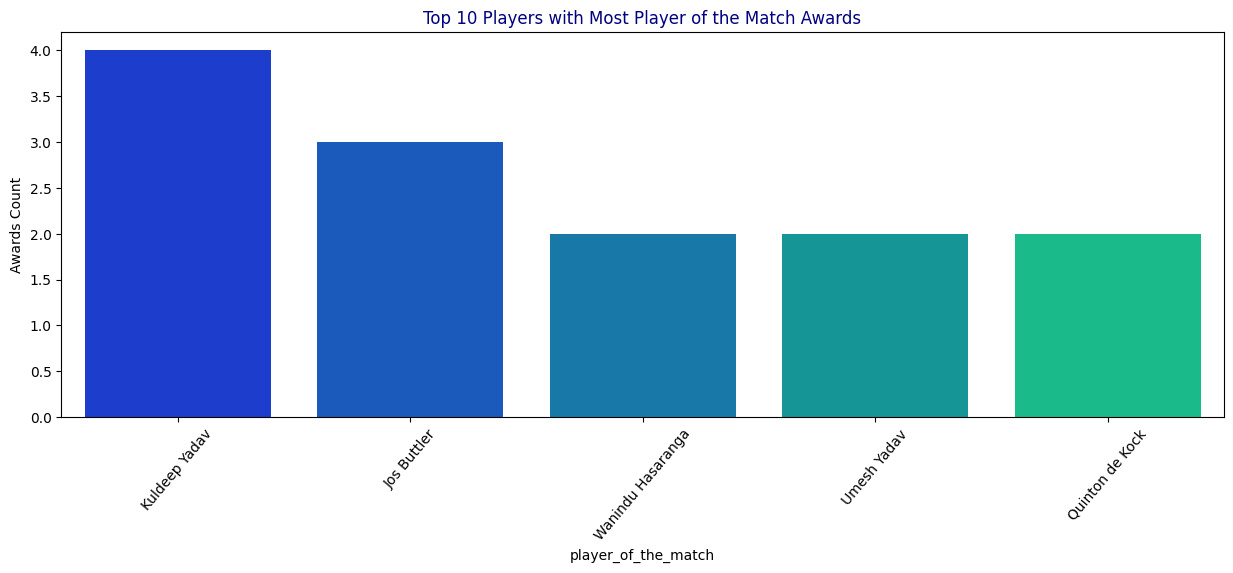

In [ ]:
plt.figure(figsize =(15,5))

sns.barplot(x = top_pom.index,
    y = top_pom.values,
    palette = "winter"
)

plt.xticks(rotation = 50)
plt.title("Top 10 Players with Most Player of the Match Awards", color = "navy")
plt.ylabel("Awards Count")
plt.show()


**Insights**

1. **Kuldeep Yadav** leads with the most Player of the Match awards.

2. **Wanindu Hasaranga and Umesh Yadav** also have significant roles in their respective teams.

3. Players like **Quinton de Kock** have fewer awards compared to the top players.

## **Conclusion**

1. This notebook provides a clean and structured starting point for an IPL data analysis project, successfully loading the dataset and performing initial feature engineering.

2. However, to truly reflect advanced data science capabilities, the project requires careful, context-aware handling of missing data rather than broad statistical imputations.

3. By populating the visualization section with targeted charts and expanding the statistical encoding, this can easily evolve into a comprehensive diagnostic analysis.

4. It is well on its way to becoming a standout artifact for your analytics portfolio.